# Data and attacks

The results rest on CIFAR-10, CIFAR-100, GTSRB and Tiny ImageNet, the `panel.datasets` of `configs/psbd_basis.json`. SVHN and EuroSAT were trained only to host SIG on an untuned recipe and are declared out of the paper in the same file. The attack registry names BadNets (all-to-one and all-to-all), Blend, SIG, WaNet, LF, Label-Consistent, BPP, Adaptive-Blend, TaCT and a `generated` reader for BackdoorBench PNG triggers, described in full in the attacks subsection of `paper/sections/appendix.tex`.

This notebook answers 4 questions in order. What does each trigger do to an image? Which images is an attack allowed to poison, at training time and at evaluation time? How does a requested poison rate turn into a realized one? And which of the trained models actually carry a backdoor, which is the population every detection number is averaged over? It runs on CPU, loads the raw test and training sets from `raw_data/`, builds every trigger from the same registry the training code uses (`attacks.build_attack`), and reads the coverage ledger `results/coverage/coverage.json`. It takes about a minute.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import json
import logging
import warnings

logging.getLogger("lightning.fabric.utilities.seed").setLevel(logging.WARNING)
# torchvision's ToTensor deprecation fires once per dataset load and says nothing
# about the numbers below.
warnings.filterwarnings("ignore", message="The transform `ToTensor", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

import scripts.paper._style  # noqa: F401  the figure style every paper figure uses
from scripts.paper._common import word_list

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline


def macro(table, name):
    """1 value of paper/tables/<table>.macros.json, the string headline.tex prints."""
    with open(f"paper/tables/{table}.macros.json") as handle:
        sidecar = json.load(handle)
    value = sidecar["macros"][name]["value"]
    return value


def show_diagram(name, width=None):
    """Embed a TikZ diagram rendered by notebooks/figures/render.py."""
    display(Image(filename=f"notebooks/figures/{name}.png", width=width))

import torch
from dataclasses import asdict

from attacks import ATTACK_NAMES, build_attack, default_config
from attacks.poisoning import (
    AttackSuccessSet,
    attack_success_label,
    is_eval_poisonable,
    is_poisonable,
    poisoned_label,
)
from data.registry import DATASET_REGISTRY
from evaluation.loaders import load_test_base
from scripts.paper._common import attack_label, dataset_label, load_coverage
from scripts.paper._style import attack_color, legend_above

DEVICE = torch.device("cpu")
DATASET = "cifar100"
TARGET_LABEL = 0
PANEL_DATASETS = ("cifar10", "cifar100", "gtsrb", "tiny")
print("torch", torch.__version__, "device", DEVICE)

torch 2.6.0+cu124 device cpu


## The attack registry

`ATTACK_NAMES` in `attacks/__init__.py` carries more entries than there are attacks. An attack is a plain record of a name, a function that stamps a trigger, a label policy and a config, not a class hierarchy, so most of the extra entries are label-policy variants of a smaller set of triggers rather than new triggers. `badnet` is an alias for `badnet_a2o`, `generated` carries no default config because it reads somebody else's PNG triggers instead of stamping its own, and every `badnet_a2m*` entry stamps the identical checkerboard under an all-to-many label policy. Filtering those out leaves 1 entry per trigger and label policy, with BadNets under 2 label policies. The cell prints the counts.

A **label policy** (`label_mode`) says which label a poisoned training image receives. **All-to-one** (a2o) relabels every poisoned image to the single target class. **All-to-all** (a2a) relabels class $y$ to $y+1$ modulo the class count. **Clean-label** keeps the true label and can only poison images that already belong to the target class, which is why SIG and Label-Consistent need their trigger to be learned without any label change.

In [2]:
# badnet is an alias, generated has no default config, and every badnet_a2m*
# stamps the identical checkerboard under a different label policy.
SKIP = ("badnet", "generated")
TRIGGER_NAMES = [name for name in ATTACK_NAMES if name not in SKIP and "a2m" not in name]

spec = DATASET_REGISTRY[DATASET]
attacks = {
    name: build_attack(name, default_config(name), spec.image_size, TARGET_LABEL)
    for name in TRIGGER_NAMES
}

registry = pd.DataFrame(
    [
        {
            "attack": name,
            "label_mode": attacks[name].label_mode,
            "config": ", ".join(
                f"{key}={value}"
                for key, value in asdict(default_config(name)).items()
                if key != "label_mode"
            ),
        }
        for name in TRIGGER_NAMES
    ]
).set_index("attack")

skipped = [n for n in ATTACK_NAMES if n not in TRIGGER_NAMES]
print(f"registry entries {len(ATTACK_NAMES)}, entries kept {len(TRIGGER_NAMES)}")
print(f"skipped {len(skipped)}: {', '.join(skipped)}")
pd.set_option("display.max_colwidth", 90)
registry

registry entries 19, entries kept 10
skipped 9: badnet, badnet_a2m2, badnet_a2m4, badnet_a2m8, badnet_a2m16, badnet_a2m32, badnet_a2m64, badnet_a2m128, generated


,label_mode,config
attack,,
badnet_a2o,all_to_one,"patch_size=3, num_targets=None"
badnet_a2a,all_to_all,"patch_size=3, num_targets=None"
blend,all_to_one,"alpha=0.2, pattern_seed=0"
sig,clean_label,"amplitude=0.157, frequency=6.0, num_targets=1"
wanet,all_to_one,"control_grid_size=4, strength=0.5, field_seed=0, cover_rate=0.0"
lf,all_to_one,"strength=0.1, cutoff=4, pattern_seed=0"
lc,clean_label,"patch_size=3, adversarial_dir=, adversarial_epsilon=0.0, num_targets=1"
bpp,all_to_one,"bit_depth=3, dither=False, cover_rate=0.0"
adaptive_blend,all_to_one,"alpha=0.2, cover_rate=0.01, pattern_seed=0, cells=4, train_cell_fraction=0.5"


## What each trigger does to 1 image

BadNets, TaCT and the checkerboard corner of Label-Consistent all stamp the same $3\times3$ pattern into a fixed corner, so their pixels are identical and any difference in their detection numbers comes from the label policy or the cover images, never from the trigger itself. Blend and Adaptive-Blend also share a pattern, but only at evaluation time. Adaptive-Blend's training trigger plants a random subset of the pattern per image and adds **cover images** (triggered images that keep their true label), which is the mechanism behind why it survives detectors built against the full pattern. The figure draws each trigger on 1 CIFAR-100 test image, with the difference image amplified to full range so a faint trigger is visible.

In [3]:
test_base, _ = load_test_base(DATASET, "raw_data")
EXAMPLE_INDEX = 7
example_image, example_label = test_base[EXAMPLE_INDEX]  # (3, 32, 32) in [0, 1]

badnet_image = attacks["badnet_a2o"].apply_trigger(example_image, EXAMPLE_INDEX)
assert torch.equal(badnet_image, attacks["badnet_a2a"].apply_trigger(example_image, EXAMPLE_INDEX))
assert torch.equal(badnet_image, attacks["tact"].apply_trigger(example_image, EXAMPLE_INDEX))

blend_image = attacks["blend"].apply_trigger(example_image, EXAMPLE_INDEX)
assert torch.equal(blend_image, attacks["adaptive_blend"].apply_trigger_eval(example_image, EXAMPLE_INDEX))
assert not torch.equal(blend_image, attacks["adaptive_blend"].apply_trigger(example_image, EXAMPLE_INDEX))

print("badnet_a2o, badnet_a2a and tact stamp identical pixels")
print("blend and adaptive_blend stamp identical pixels at evaluation time only")
print(f"example image {tuple(example_image.shape)}, class {example_label}")

badnet_a2o, badnet_a2a and tact stamp identical pixels
blend and adaptive_blend stamp identical pixels at evaluation time only
example image (3, 32, 32), class 14


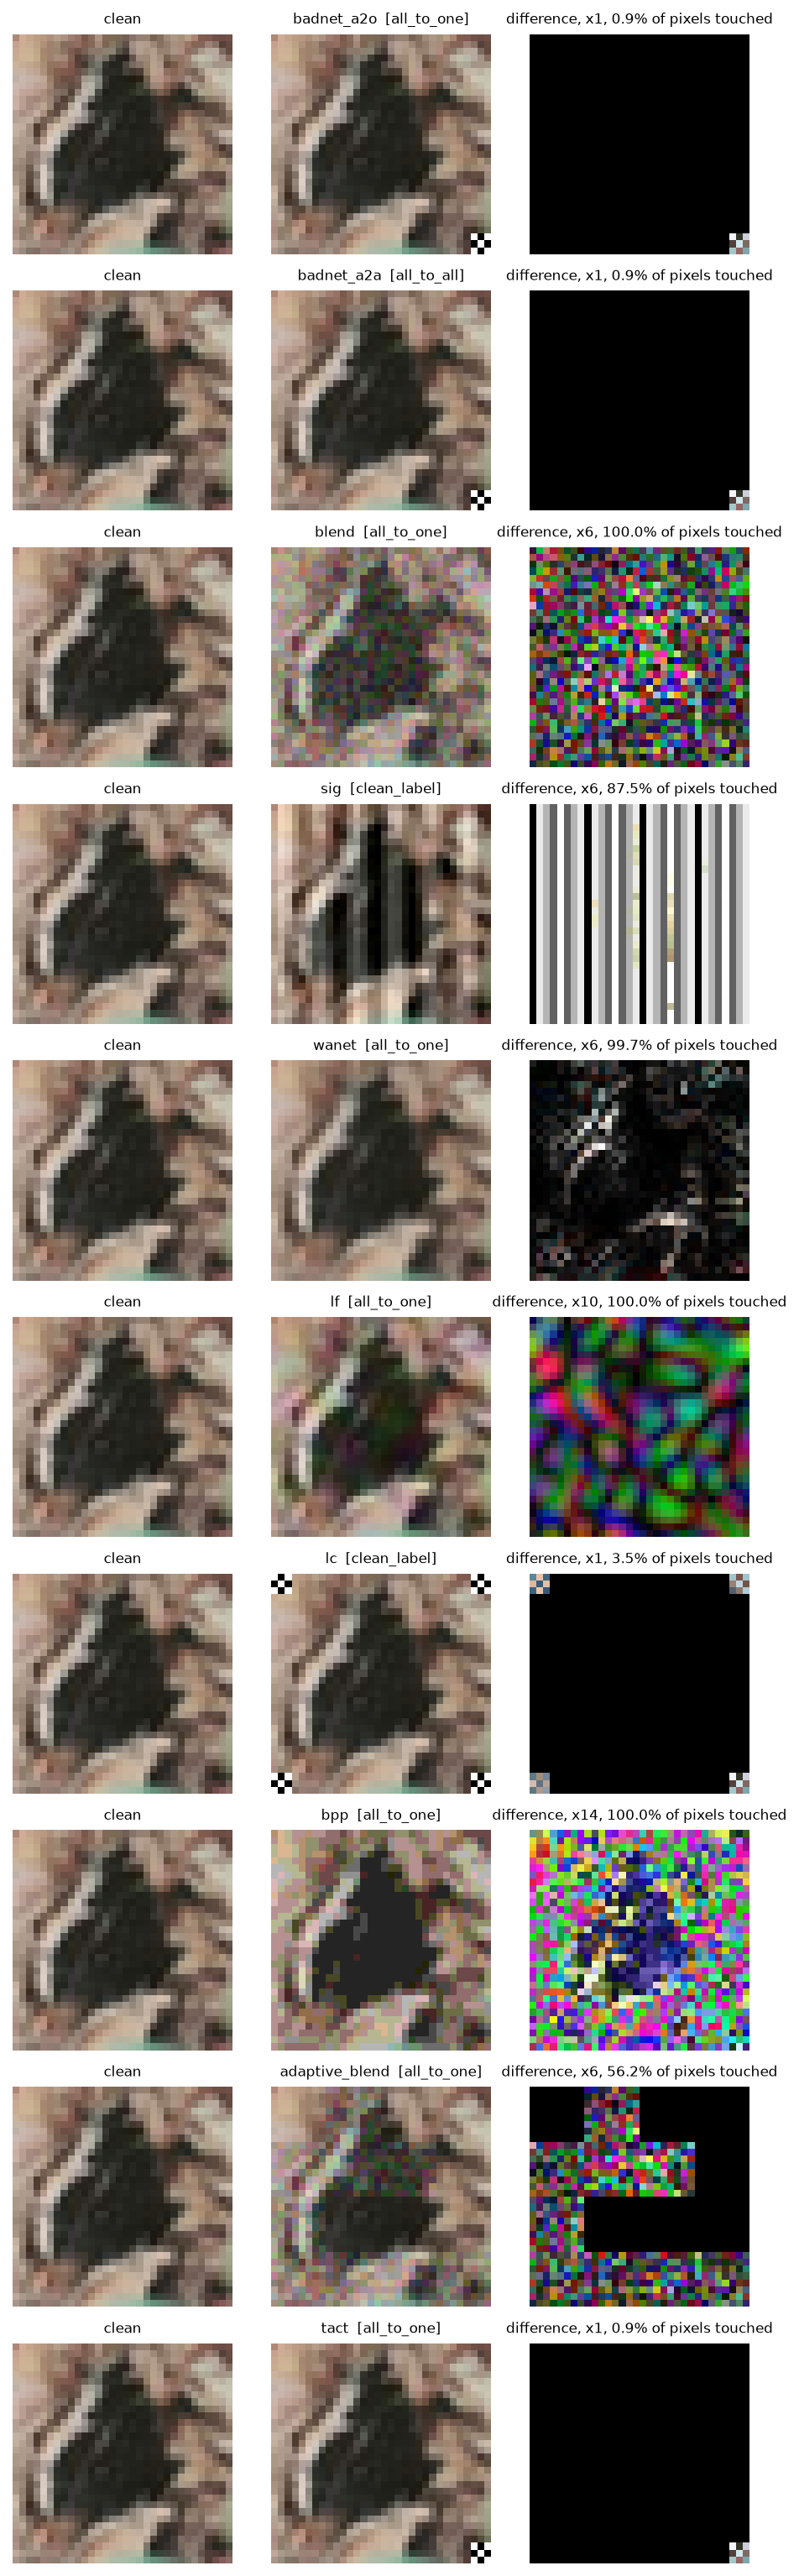

In [4]:
def trigger_row_statistics(attack, image, index):
    triggered = attack.apply_trigger(image, index)  # (3, H, W)
    difference = (triggered - image).abs()  # (3, H, W)
    statistics = {
        "triggered": triggered,
        "difference": difference,
        "max_abs": float(difference.max()),
        "mean_abs": float(difference.mean()),
        "touched_fraction": float((difference > 1e-6).float().mean()),
    }
    return statistics


def plot_trigger_grid(attacks, image, index):
    figure, axes = plt.subplots(len(attacks), 3, figsize=(6.4, 2.05 * len(attacks)))
    for axis_row, (name, attack) in zip(axes, attacks.items()):
        row = trigger_row_statistics(attack, image, index)
        amplified = row["difference"] / max(row["max_abs"], 1e-8)
        for axis, picture, title in zip(
            axis_row,
            [image, row["triggered"], amplified],
            [
                "clean",
                f"{name}  [{attack.label_mode}]",
                f"difference, x{1 / max(row['max_abs'], 1e-8):.0f}, "
                f"{100 * row['touched_fraction']:.1f}% of pixels touched",
            ],
        ):
            axis.imshow(picture.permute(1, 2, 0).clamp(0, 1).numpy(), interpolation="nearest")
            axis.set_title(title, fontsize=8)
            axis.axis("off")
    figure.tight_layout()
    return figure


plot_trigger_grid(attacks, example_image, EXAMPLE_INDEX)
plt.show()

Read the right column. The patch triggers (BadNets in both label modes, TaCT and Label-Consistent's corner) change a small square and nothing else. Blend, SIG, LF, BPP and Adaptive-Blend change every pixel by a small amount, and WaNet moves pixels by a smooth warp, so its difference concentrates on edges. The figure shows 1 image of 1 dataset and does not show that a trigger's footprint in tokens depends on the resize to $224$, which the ViT sees. The next figure turns the 2 numbers each row carries into a map of the trigger families.

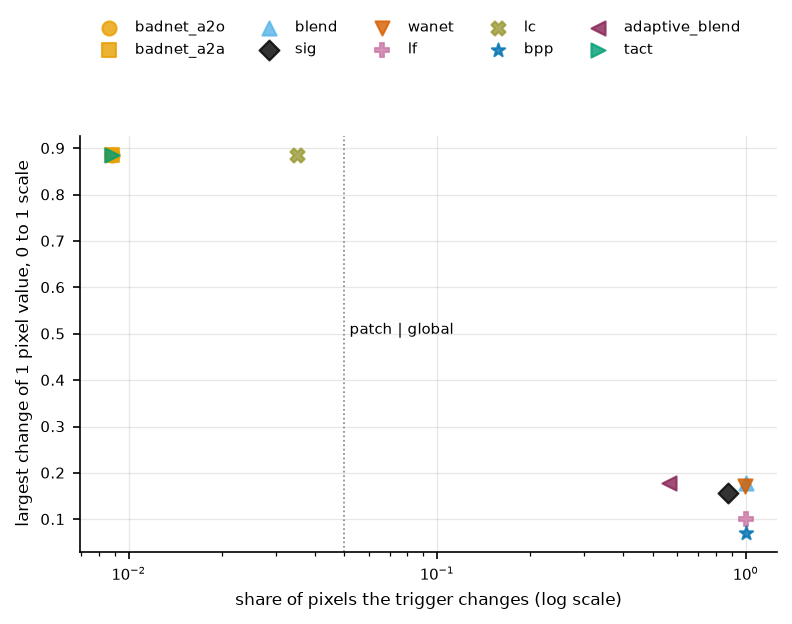

In [5]:
trigger_statistics = pd.DataFrame(
    [
        {"attack": name, **{k: v for k, v in trigger_row_statistics(attack, example_image, EXAMPLE_INDEX).items() if not torch.is_tensor(v)}}
        for name, attack in attacks.items()
    ]
).set_index("attack")

figure, axis = plt.subplots(figsize=(6.0, 3.6))
markers = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]
for (name, row), marker in zip(trigger_statistics.iterrows(), markers):
    axis.scatter(row["touched_fraction"], row["max_abs"], s=46, marker=marker, color=attack_color(name), label=name, alpha=0.8)
axis.set_xscale("log")
axis.set_xlabel("share of pixels the trigger changes (log scale)")
axis.set_ylabel("largest change of 1 pixel value, 0 to 1 scale")
axis.axvline(0.05, color="gray", ls=":", lw=0.8)
axis.text(0.05, 0.5, " patch | global", fontsize=7)
legend_above(figure, [axis], columns=5)
plt.show()
trigger_statistics.round(4)

import torch.nn.functional as F

# A token counts as touched when any pixel of its 16 by 16 patch changed after the
# resize to 224 the model applies.
badnet_difference = (attacks["badnet_a2o"].apply_trigger(example_image, EXAMPLE_INDEX) - example_image).abs().sum(0)  # (32, 32)
resized_difference = F.interpolate(badnet_difference[None, None], size=224, mode="nearest")[0, 0]  # (224, 224)
badnet_tokens = int((resized_difference.reshape(14, 16, 14, 16).amax(dim=(1, 3)) > 0).sum())
patch_names = ["badnet_a2o", "lc", "tact"]
patch_share_max = trigger_statistics.loc[patch_names, "touched_fraction"].max()
global_names = [n for n in trigger_statistics.index if n not in patch_names + ["badnet_a2a"]]
assert trigger_statistics.loc[global_names, "touched_fraction"].min() > 0.5 > patch_share_max

In [6]:
display(Markdown(rf"""
2 families separate cleanly. **Patch triggers** touch at most {patch_share_max:.1%} of the pixels ({trigger_statistics.loc["badnet_a2o", "touched_fraction"]:.1%} for the BadNets square, {trigger_statistics.loc["lc", "touched_fraction"]:.1%} for Label-Consistent's corner patches) and change them by up to {trigger_statistics.loc["badnet_a2o", "max_abs"]:.2f}. **Global triggers** touch at least {trigger_statistics.loc[global_names, "touched_fraction"].min():.0%} of the pixels and change each by a small amount (Blend at $\alpha={default_config("blend").alpha}$ moves a pixel by up to {trigger_statistics.loc["blend", "max_abs"]:.2f}, SIG by up to its amplitude {default_config("sig").amplitude}). This split carries through the whole project. The BadNets square touches {badnet_tokens} of ViT's 196 patch tokens after the resize, so a probe that removes whole tokens can remove it, while a global trigger is present in every token and survives the removal of any subset. `mechanism.ipynb` tests exactly this. The figure does not show WaNet's peculiarity, a warp whose per-pixel change depends on the image content, so its position here moves from image to image.
"""))


2 families separate cleanly. **Patch triggers** touch at most 3.5% of the pixels (0.9% for the BadNets square, 3.5% for Label-Consistent's corner patches) and change them by up to 0.89. **Global triggers** touch at least 56% of the pixels and change each by a small amount (Blend at $\alpha=0.2$ moves a pixel by up to 0.18, SIG by up to its amplitude 0.157). This split carries through the whole project. The BadNets square touches 4 of ViT's 196 patch tokens after the resize, so a probe that removes whole tokens can remove it, while a global trigger is present in every token and survives the removal of any subset. `mechanism.ipynb` tests exactly this. The figure does not show WaNet's peculiarity, a warp whose per-pixel change depends on the image content, so its position here moves from image to image.


## The same triggers on every panel dataset

The 4 datasets differ in resolution and content. CIFAR-10 and CIFAR-100 are $32\times32$ natural images with 10 and 100 classes, GTSRB is traffic signs resized to $32\times32$ with 43 classes, and Tiny ImageNet is $64\times64$ with 200 classes. The registry builds each trigger at the dataset's own `image_size`, so a BadNets patch is 3 pixels wide on every dataset and therefore covers a smaller share of a Tiny image.

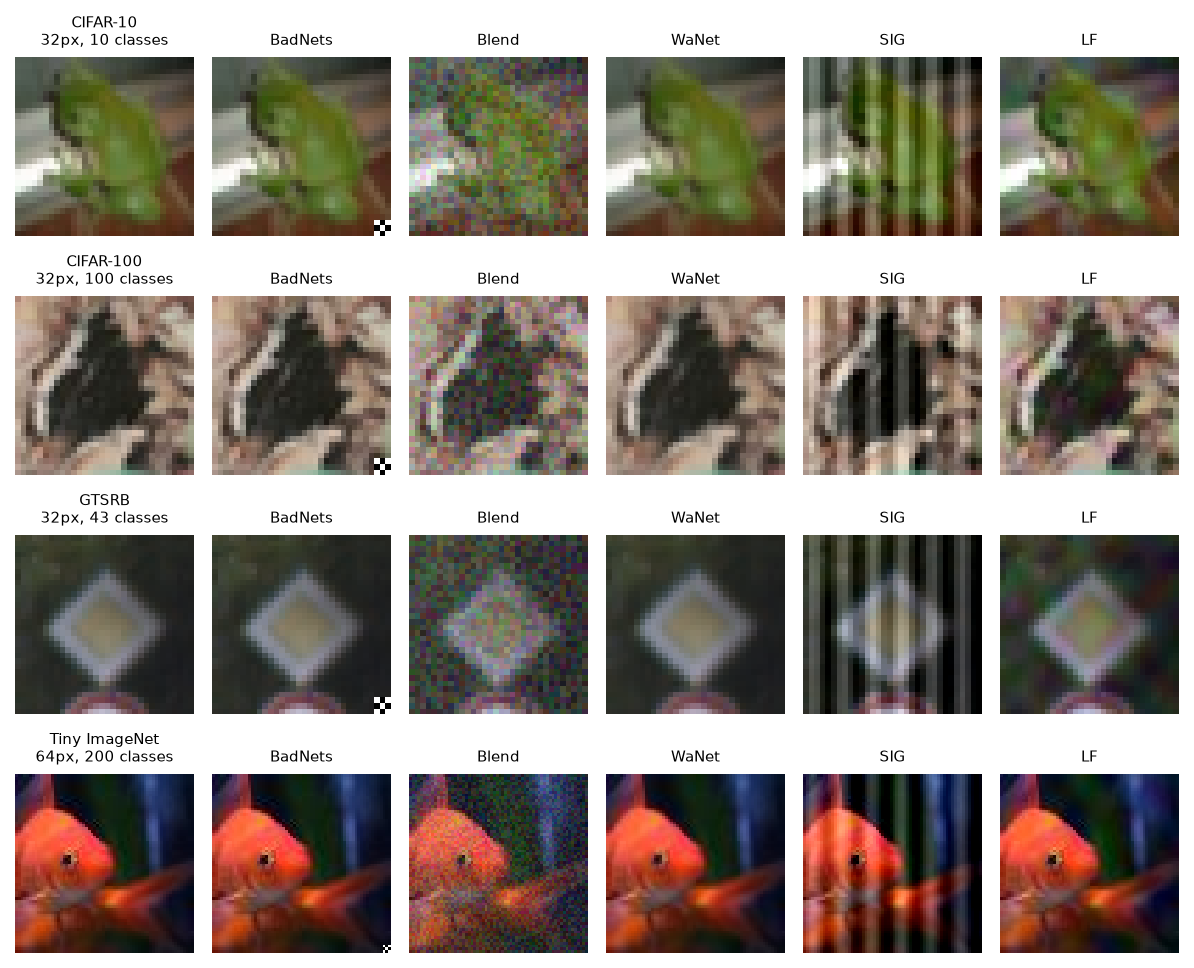

In [7]:
SHOWN_ATTACKS = ("badnet_a2o", "blend", "wanet", "sig", "lf")
dataset_examples = {}
for dataset in PANEL_DATASETS:
    base, dataset_spec = load_test_base(dataset, "raw_data")
    image, label = base[EXAMPLE_INDEX]
    dataset_examples[dataset] = (dataset_spec, image, label)

figure, axes = plt.subplots(len(PANEL_DATASETS), len(SHOWN_ATTACKS) + 1, figsize=(8.0, 6.6))
for axis_row, dataset in zip(axes, PANEL_DATASETS):
    dataset_spec, image, label = dataset_examples[dataset]
    axis_row[0].imshow(image.permute(1, 2, 0).numpy(), interpolation="nearest")
    axis_row[0].set_title(f"{dataset_label(dataset)}\n{dataset_spec.image_size}px, {dataset_spec.num_classes} classes", fontsize=7)
    for axis, name in zip(axis_row[1:], SHOWN_ATTACKS):
        attack = build_attack(name, default_config(name), dataset_spec.image_size, TARGET_LABEL)
        triggered = attack.apply_trigger(image, EXAMPLE_INDEX)  # (3, H, W)
        axis.imshow(triggered.permute(1, 2, 0).clamp(0, 1).numpy(), interpolation="nearest")
        axis.set_title(attack_label(name), fontsize=7)
for axis in axes.flat:
    axis.axis("off")
figure.tight_layout()
plt.show()

Each row is test image 7 of 1 dataset with 5 triggers applied. The BadNets square is visible in the corner on every dataset and is proportionally smallest on Tiny, where after the resize it covers 1 token rather than 4, a fact `mechanism.ipynb` needs when it counts trigger tokens. The global triggers are hard to see at this size, which is the point of them. The figure does not show whether a model learned any of these triggers, which the ledger section below answers.

## The poisoning protocol

A trigger is only half of an attack. The other half is the label policy, and a sample is not always eligible for the same reason at training time and at evaluation time. For a dirty-label attack (all-to-one and all-to-all) the 2 questions agree: an image is poisonable if it is not already the target, and the same condition asks whether the trigger fools it at test time. For a clean-label attack the 2 questions are opposites. Training can only poison an image that already carries the target label, since a clean-label attack never touches the label, while evaluation only makes sense on an image that does not, since the question being asked is whether the trigger fools a non-target image into the target class.

`attacks.poisoning` holds the 4 functions. `is_poisonable` and `poisoned_label` answer the training question, `is_eval_poisonable` and `attack_success_label` the evaluation question. The table evaluates them on 3 sample labels of CIFAR-100 with target 0.

In [8]:
NUM_CLASSES = spec.num_classes
SAMPLE_LABELS = [0, 1, 42]

policy = pd.DataFrame(
    [
        {
            "label_mode": mode,
            "true_label": label,
            "train_eligible": is_poisonable(mode, label, TARGET_LABEL),
            "train_label": poisoned_label(mode, label, TARGET_LABEL, NUM_CLASSES),
            "eval_eligible": is_eval_poisonable(mode, label, TARGET_LABEL),
            "eval_target": attack_success_label(mode, label, TARGET_LABEL, NUM_CLASSES),
        }
        for mode in ("all_to_one", "all_to_all", "clean_label")
        for label in SAMPLE_LABELS
    ]
).set_index(["label_mode", "true_label"])

policy

train_eligible  train_label  eval_eligible  \
label_mode  true_label                                               
all_to_one  0                    False            0          False   
            1                     True            0           True   
            42                    True            0           True   
all_to_all  0                     True            1           True   
            1                     True            2           True   
            42                    True           43           True   
clean_label 0                     True            0          False   
            1                    False            1           True   
            42                   False           42           True   

                        eval_target  
label_mode  true_label               
all_to_one  0                     0  
            1                     0  
            42                    0  
all_to_all  0                     1  
            1                     2  
            42                   43  
clean_label 0                     0  
            1                     0  
            42                    0

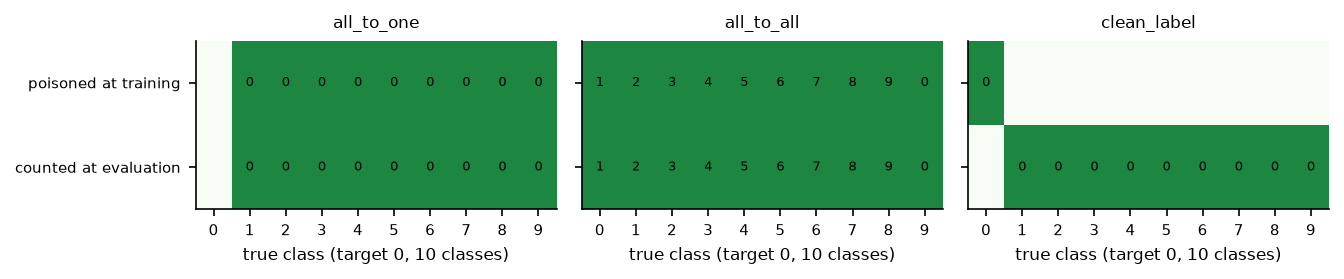

In [9]:
POLICY_CLASSES = 10
modes = ("all_to_one", "all_to_all", "clean_label")
eligibility = np.array(
    [
        [
            [is_poisonable(mode, label, TARGET_LABEL) for label in range(POLICY_CLASSES)],
            [is_eval_poisonable(mode, label, TARGET_LABEL) for label in range(POLICY_CLASSES)],
        ]
        for mode in modes
    ],
    dtype=float,
)  # (modes, 2 questions, classes)
assert eligibility.shape == (len(modes), 2, POLICY_CLASSES)

figure, axes = plt.subplots(1, len(modes), figsize=(9.0, 1.9), sharey=True)
for axis, mode, grid in zip(axes, modes, eligibility):
    axis.imshow(grid, cmap="Greens", vmin=0, vmax=1.3, aspect="auto")
    for question in range(2):
        for label in range(POLICY_CLASSES):
            target_text = (poisoned_label if question == 0 else attack_success_label)(mode, label, TARGET_LABEL, POLICY_CLASSES)
            axis.text(label, question, str(target_text) if grid[question, label] else "", ha="center", va="center", fontsize=6)
    axis.set_title(mode, fontsize=8)
    axis.set_xticks(range(POLICY_CLASSES))
    axis.set_xlabel("true class (target 0, 10 classes)")
    axis.grid(False)
axes[0].set_yticks([0, 1], labels=["poisoned at training", "counted at evaluation"])
figure.tight_layout()
plt.show()

A green cell is an eligible image, and the digit in it is the label training writes (top row) or the label evaluation asks the trigger to reach (bottom row). The `clean_label` panel is the only one whose 2 rows are complements: training may only touch the target class 0, and evaluation counts every class except 0. `attacks.poisoning.AttackSuccessSet` is the single class both the training entrypoint and the checkpoint-metadata reader (`data.splits`) use to build the evaluation pool, so a clean-label evaluation set is never accidentally the training pool. The figure does not show TaCT, which is all-to-one but restricts both questions to its `source_classes` (class 1 by default), so its evaluation set is the test images of class 1 alone. The next cell checks the class on real data.

In [10]:
import torchvision.transforms.v2 as transforms_v2

from data.loading import extract_labels

test_labels = extract_labels(test_base)
sig_attack = attacks["sig"]
normalize = transforms_v2.Normalize(mean=spec.mean, std=spec.std)
success_set = AttackSuccessSet(test_base, test_labels, sig_attack, normalize, NUM_CLASSES)

served_targets = {int(success_set[position][1]) for position in range(0, len(success_set), 97)}
served_true_labels = {test_labels[i] for i in success_set.indices}

print(f"clean-label evaluation set size {len(success_set)} of {len(test_labels)} test images")
print(f"true classes it draws from       {len(served_true_labels)} of {NUM_CLASSES}, excludes the target: "
      f"{TARGET_LABEL not in served_true_labels}")
print(f"labels the trigger is asked to reach {served_targets}")
assert served_targets == {TARGET_LABEL}

tact_set = AttackSuccessSet(test_base, test_labels, attacks["tact"], normalize, NUM_CLASSES)
tact_true_labels = {test_labels[i] for i in tact_set.indices}
print(f"TaCT evaluation set size {len(tact_set)}, true classes {tact_true_labels}")

clean-label evaluation set size 9900 of 10000 test images
true classes it draws from       99 of 100, excludes the target: True
labels the trigger is asked to reach {0}
TaCT evaluation set size 100, true classes {1}


In [11]:
display(Markdown(rf"""
On {dataset_label(DATASET)} the SIG evaluation set is the {len(success_set)} test images outside class {TARGET_LABEL}, and TaCT's is the {len(tact_set)} test images of its source class {sorted(tact_true_labels)[0]}. A small TaCT evaluation set matters twice later. Its ASR rests on few images, and the PSBD analysis pairs clean and triggered images from the same pool, so a TaCT model yields only as many detection pairs as its source class has analysis images. The question the eligibility rule raises next is how many training images an attack can actually poison.
"""))


On CIFAR-100 the SIG evaluation set is the 9900 test images outside class 0, and TaCT's is the 100 test images of its source class 1. A small TaCT evaluation set matters twice later. Its ASR rests on few images, and the PSBD analysis pairs clean and triggered images from the same pool, so a TaCT model yields only as many detection pairs as its source class has analysis images. The question the eligibility rule raises next is how many training images an attack can actually poison.


## Poison-rate mechanics

A requested poison rate is read against the whole training set, but the images an attack is allowed to draw from can be far smaller than that. `attacks.poisoning.choose_poison_indices` draws without replacement from the eligible pool, seeded by `data.splits.PSBD_SPLIT_SEED` and clamps silently once the request exceeds it, so a requested rate above the pool's share trains the identical index set as the cap itself.

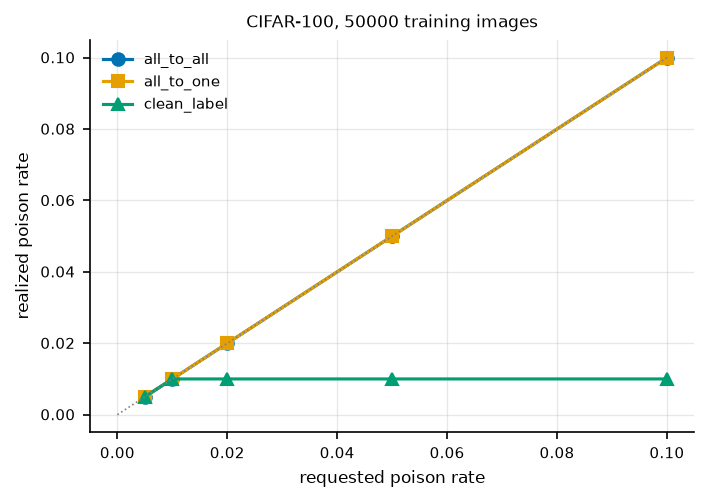

In [12]:
from attacks.poisoning import choose_poison_indices
from data.loading import base_image_transform, load_clean_datasets
from data.splits import PSBD_SPLIT_SEED

RATES = (0.005, 0.01, 0.02, 0.05, 0.10)
MODE_ATTACKS = {"all_to_one": "badnet_a2o", "all_to_all": "badnet_a2a", "clean_label": "sig"}

train_set, _ = load_clean_datasets(DATASET, base_image_transform(spec.image_size), "raw_data")
train_labels = extract_labels(train_set)

rate_rows = []
for label_mode, attack_name in MODE_ATTACKS.items():
    attack = build_attack(attack_name, default_config(attack_name), spec.image_size, TARGET_LABEL)
    for rate in RATES:
        chosen = choose_poison_indices(train_labels, attack, rate, seed=PSBD_SPLIT_SEED)
        requested_count = int(round(rate * len(train_labels)))
        rate_rows.append(
            {
                "label_mode": label_mode,
                "requested_rate": rate,
                "requested_count": requested_count,
                "realized_count": len(chosen),
                "realized_rate": len(chosen) / len(train_labels),
                "capped": len(chosen) < requested_count,
            }
        )
rates_frame = pd.DataFrame(rate_rows)

figure, axis = plt.subplots(figsize=(5.2, 3.4))
for (label_mode, rows), marker in zip(rates_frame.groupby("label_mode"), ("o", "s", "^")):
    axis.plot(rows["requested_rate"], rows["realized_rate"], marker=marker, label=label_mode)
axis.plot([0, 0.1], [0, 0.1], color="gray", ls=":", lw=0.8)
axis.set_xlabel("requested poison rate")
axis.set_ylabel("realized poison rate")
axis.set_title(f"{dataset_label(DATASET)}, {len(train_labels)} training images", fontsize=8)
axis.legend()
plt.show()
rates_frame.set_index(["label_mode", "requested_rate"]).round(5)

clean_label_cap = rates_frame.loc[rates_frame["label_mode"] == "clean_label", "realized_rate"].max()
target_count = int((np.array(train_labels) == TARGET_LABEL).sum())

In [13]:
display(Markdown(rf"""
`all_to_one` and `all_to_all` read back the rate they were asked for and lie on the diagonal, because a dirty-label pool is almost the whole training set. `clean_label` bends flat at {clean_label_cap:.0%} on {dataset_label(DATASET)}, because its pool is the target class alone and that class holds {target_count} of the {len(train_labels)} training images. The cap is arithmetic rather than a bug, and every rate above it trains the same model. The next figure measures the cap on every panel dataset, which is what decided the target class of the clean-label runs.
"""))


`all_to_one` and `all_to_all` read back the rate they were asked for and lie on the diagonal, because a dirty-label pool is almost the whole training set. `clean_label` bends flat at 1% on CIFAR-100, because its pool is the target class alone and that class holds 500 of the 50000 training images. The cap is arithmetic rather than a bug, and every rate above it trains the same model. The next figure measures the cap on every panel dataset, which is what decided the target class of the clean-label runs.


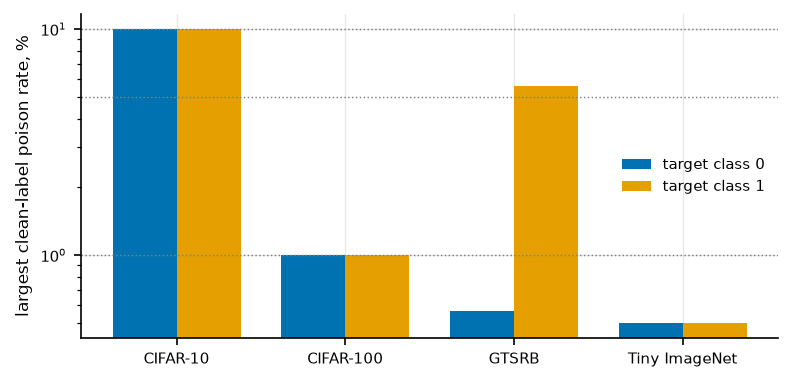

In [14]:
cap_rows = []
for dataset in PANEL_DATASETS:
    dataset_spec = DATASET_REGISTRY[dataset]
    dataset_train, _ = load_clean_datasets(dataset, base_image_transform(dataset_spec.image_size), "raw_data")
    labels = np.array(extract_labels(dataset_train))  # (n_train,)
    for target in (0, 1):
        cap_rows.append(
            {"dataset": dataset_label(dataset), "target class": target, "clean-label cap": float((labels == target).mean()), "train images": len(labels)}
        )
caps = pd.DataFrame(cap_rows)

figure, axis = plt.subplots(figsize=(6.0, 2.8))
width = 0.38
positions = np.arange(len(PANEL_DATASETS))  # (datasets,)
for offset, target in zip((-width / 2, width / 2), (0, 1)):
    rows = caps[caps["target class"] == target]
    axis.bar(positions + offset, rows["clean-label cap"] * 100, width=width, label=f"target class {target}")
for rate in (1, 5, 10):
    axis.axhline(rate, color="gray", ls=":", lw=0.7)
axis.set_xticks(positions, labels=[dataset_label(d) for d in PANEL_DATASETS])
axis.set_ylabel("largest clean-label poison rate, %")
axis.set_yscale("log")
axis.legend()
plt.show()
caps.pivot(index="dataset", columns="target class", values="clean-label cap").round(4)

cap_table = caps.pivot(index="dataset", columns="target class", values="clean-label cap")  # (datasets, 2)
capped_below_5 = [d for d in cap_table.index if cap_table.loc[d, 0] < 0.05]

In [15]:
display(Markdown(rf"""
The dotted lines are the 3 panel rates. At target class 0 the clean-label cap is {word_list([f"{cap_table.loc[d, 0]:.2%} on {d}" for d in cap_table.index])}, so SIG and Label-Consistent cannot reach the 5% and 10% rows on {len(capped_below_5)} of the {len(cap_table)} datasets ({word_list(capped_below_5)}). GTSRB's class 1 holds {cap_table.loc["GTSRB", 1]:.2%} of its training set, which is why the clean-label GTSRB runs use target class 1 and carry a `_tl1` tag in their folder name, and why Label-Consistent carries Turner's adversarial bases (`_adv`, generated by `cli.lc_bases`). `docs/clean-label-rate-caps.md` is the full record. The figure does not say whether a capped attack implanted, which the ledger answers next.
"""))


The dotted lines are the 3 panel rates. At target class 0 the clean-label cap is 10.00% on CIFAR-10, 1.00% on CIFAR-100, 0.56% on GTSRB and 0.50% on Tiny ImageNet, so SIG and Label-Consistent cannot reach the 5% and 10% rows on 3 of the 4 datasets (CIFAR-100, GTSRB and Tiny ImageNet). GTSRB's class 1 holds 5.63% of its training set, which is why the clean-label GTSRB runs use target class 1 and carry a `_tl1` tag in their folder name, and why Label-Consistent carries Turner's adversarial bases (`_adv`, generated by `cli.lc_bases`). `docs/clean-label-rate-caps.md` is the full record. The figure does not say whether a capped attack implanted, which the ledger answers next.


## Which trained models carry a backdoor

Every checkpoint trains 15 epochs of Adam at learning rate $10^{-4}$ with weight decay $10^{-4}$, 1 seed, `checkpoints/<folder>/args.json` recording the recipe. `cli.evaluate` measures ASR on the evaluation set built above and clean accuracy on the clean test set, and `scripts/coverage_ledger.py` classes each checkpoint as the start of the tour defines (`clears`, `below_bar`, `source_mapped`, `diverged`). The heatmap shows each panel checkpoint's ASR, 1 panel per dataset, with its class written in the cell.

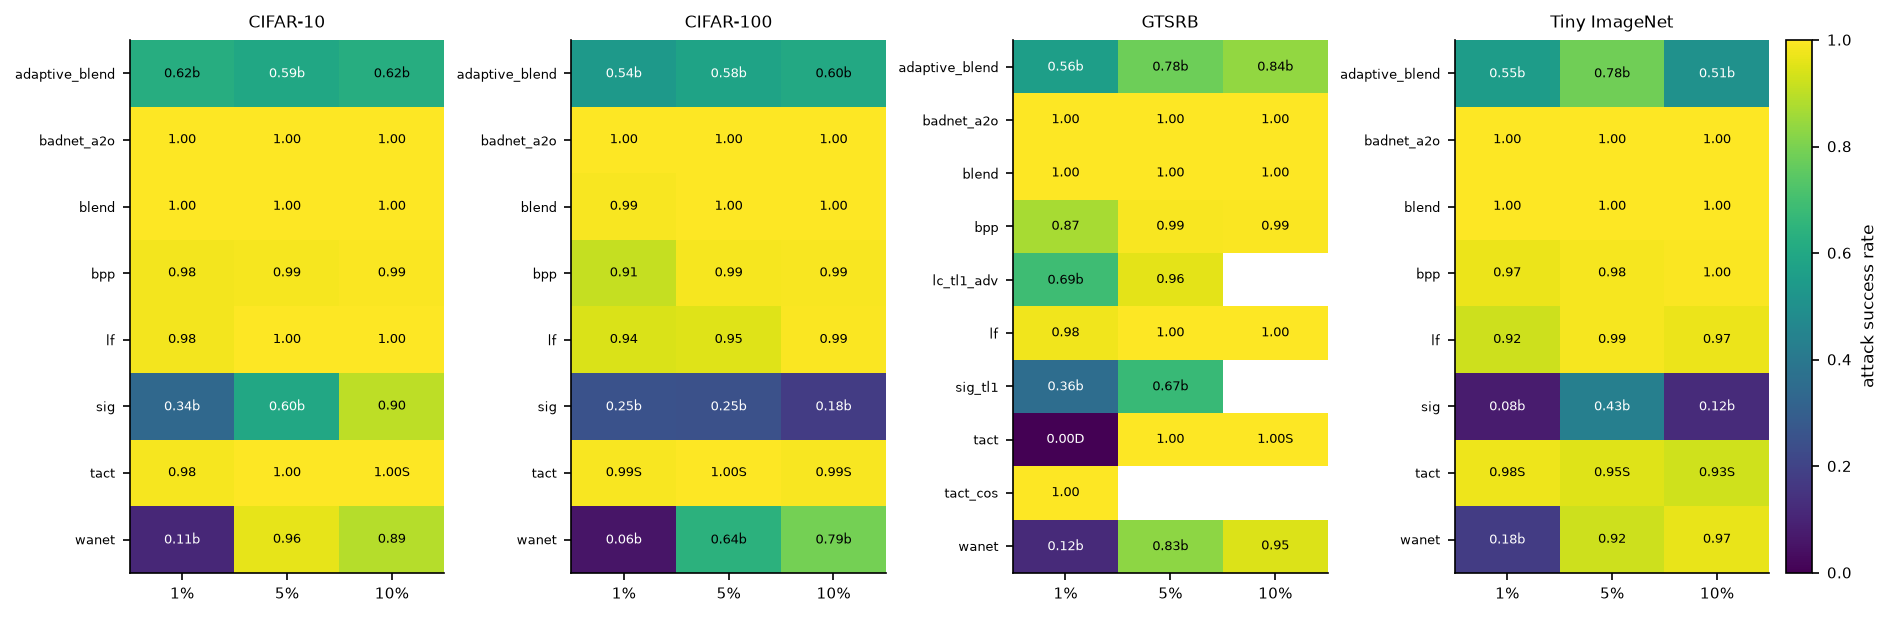

cell suffix: none = clears, b = below the 0.85 bar, S = source-mapped TaCT, D = diverged
ASR bar 0.85, ledger written 2026-09-29T16:00:43+00:00


In [16]:
coverage = load_coverage("results")
ledger = pd.DataFrame(coverage["cells"])
RATE_TOKENS = {0.01: "1%", 0.05: "5%", 0.1: "10%"}
CLASS_CODES = {"clears": "", "below_bar": "b", "source_mapped": "S", "diverged": "D"}


def row_name(folder, dataset):
    body = folder.removeprefix(f"vit_{dataset}_")
    for token in ("_0_01", "_0_05", "_0_1"):
        body = body.replace(token, "")
    return body


ledger["row"] = [row_name(f, d) for f, d in zip(ledger["folder_name"], ledger["dataset"])]
ledger["rate"] = ledger["poison_rate"].map(RATE_TOKENS)

figure, axes = plt.subplots(1, len(PANEL_DATASETS), figsize=(12.5, 4.0), layout="constrained")
for axis, dataset in zip(axes, PANEL_DATASETS):
    rows = ledger[ledger["dataset"] == dataset]
    grid = rows.pivot_table(index="row", columns="rate", values="asr", aggfunc="first").reindex(columns=["1%", "5%", "10%"])
    classes = rows.pivot_table(index="row", columns="rate", values="asr_class", aggfunc="first").reindex(columns=["1%", "5%", "10%"])
    image = axis.imshow(grid.to_numpy(dtype=float), cmap="viridis", vmin=0, vmax=1, aspect="auto")
    for r in range(grid.shape[0]):
        for c in range(grid.shape[1]):
            value, asr_class = grid.iat[r, c], classes.iat[r, c]
            if isinstance(asr_class, str):
                shown = "" if pd.isna(value) else f"{value:.2f}"
                axis.text(c, r, f"{shown}{CLASS_CODES[asr_class]}", ha="center", va="center", fontsize=6,
                          color="white" if (not pd.isna(value) and value < 0.6) else "black")
    axis.set_xticks(range(3), labels=grid.columns)
    axis.set_yticks(range(len(grid)), labels=grid.index, fontsize=6)
    axis.set_title(dataset_label(dataset), fontsize=8)
    axis.grid(False)
figure.colorbar(image, ax=axes, fraction=0.02, pad=0.01, label="attack success rate")
plt.show()
print("cell suffix: none = clears, b = below the 0.85 bar, S = source-mapped TaCT, D = diverged")
print(f"ASR bar {coverage['asr_bar']}, ledger written {coverage['generated_at']}")

# Every sentence of the reading below is a query on the ledger, so it is computed here.
clears = ledger["asr_class"] == "clears"
always_clear = sorted(
    attack_label(a) for a, rows in ledger.groupby("attack")
    if rows["poison_rate"].nunique() == 3 and rows["dataset"].nunique() == len(PANEL_DATASETS) and (rows["asr_class"] == "clears").all()
)
adaptive_blend_clears = int((clears & (ledger["attack"] == "adaptive_blend")).sum())
clearing_names = lambda attack: [f"`{f}`" for f in ledger.loc[clears & (ledger["attack"] == attack), "folder_name"]]
wanet_rates = sorted(ledger.loc[clears & (ledger["attack"] == "wanet"), "poison_rate"].unique())
wanet_datasets = sorted(dataset_label(d) for d in ledger.loc[clears & (ledger["attack"] == "wanet"), "dataset"].unique())
source_mapped_count = int((ledger["asr_class"] == "source_mapped").sum())
diverged_rows = ledger[ledger["asr_class"] == "diverged"]

In [17]:
display(Markdown(rf"""
{word_list(always_clear)} implant at every rate on every dataset. Adaptive-Blend {"never clears the bar" if adaptive_blend_clears == 0 else f"clears on only {adaptive_blend_clears} cells"}, which is its design, since its partial training trigger and its cover images trade ASR for stealth, so it is absent from every ViT detection table. SIG clears only as {" and ".join(clearing_names("sig"))}, the SIG model of the panel. Label-Consistent clears only as {" and ".join(clearing_names("lc"))}, with target class 1 and adversarial bases. WaNet clears at {" and ".join(f"{r:.0%}" for r in wanet_rates)} and only on {word_list(wanet_datasets)}. TaCT reaches a high ASR wherever it trained without collapsing,  but {source_mapped_count} of its cells are marked `S`. {" and ".join(f"`{f}`" for f in diverged_rows["folder_name"])} diverged (`D`, clean accuracy {diverged_rows["clean_accuracy"].iloc[0]:.2f}) and was retrained with a cosine schedule as `tact_cos`. The heatmap does not show clean accuracy, which the next figure adds. It also does not explain the `S` class, which the TaCT figure after it does.
"""))


BPP, BadNets, Blend and LF implant at every rate on every dataset. Adaptive-Blend never clears the bar, which is its design, since its partial training trigger and its cover images trade ASR for stealth, so it is absent from every ViT detection table. SIG clears only as `vit_cifar10_sig_0_1`, the SIG model of the panel. Label-Consistent clears only as `vit_gtsrb_lc_0_05_tl1_adv`, with target class 1 and adversarial bases. WaNet clears at 5% and 10% and only on CIFAR-10, GTSRB and Tiny ImageNet. TaCT reaches a high ASR wherever it trained without collapsing,  but 8 of its cells are marked `S`. `vit_gtsrb_tact_0_01` diverged (`D`, clean accuracy 0.12) and was retrained with a cosine schedule as `tact_cos`. The heatmap does not show clean accuracy, which the next figure adds. It also does not explain the `S` class, which the TaCT figure after it does.


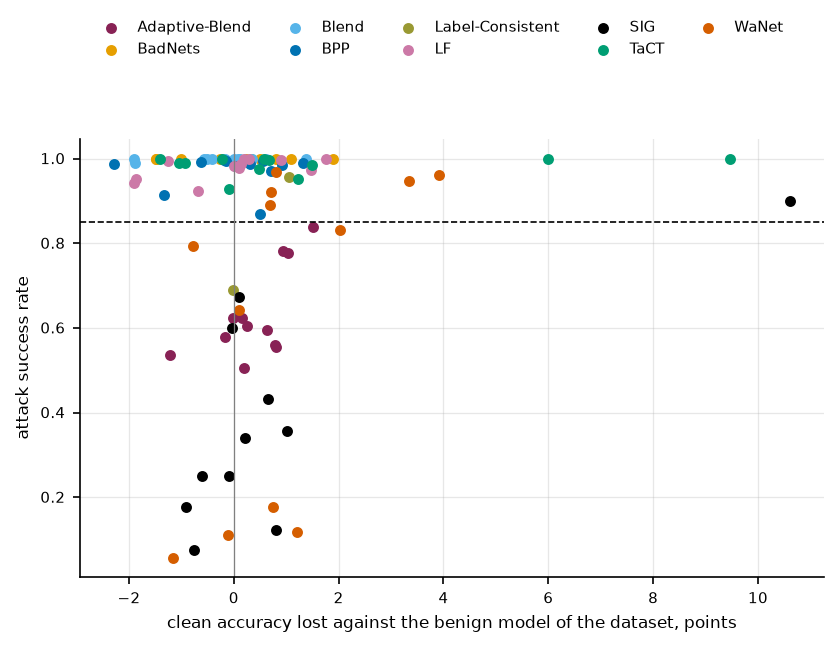

largest clean-accuracy drop among clearing cells: 10.6 points


In [18]:
ledger["accuracy_drop"] = ledger["clean_accuracy_benign"] - ledger["clean_accuracy"]
shown = ledger[ledger["asr_class"] != "diverged"]

figure, axis = plt.subplots(figsize=(6.4, 3.8))
for attack, rows in shown.groupby("attack"):
    axis.scatter(rows["accuracy_drop"] * 100, rows["asr"], s=18, color=attack_color(attack), label=attack_label(attack))
axis.axhline(coverage["asr_bar"], color="black", lw=0.8, ls="--")
axis.axvline(0, color="gray", lw=0.6)
axis.set_xlabel("clean accuracy lost against the benign model of the dataset, points")
axis.set_ylabel("attack success rate")
legend_above(figure, [axis], columns=5)
plt.show()
print(f"largest clean-accuracy drop among clearing cells: "
      f"{100 * ledger.loc[ledger['asr_class'] == 'clears', 'accuracy_drop'].max():.1f} points")

within_two = int((ledger["accuracy_drop"].abs() <= 0.02).sum())
largest_drops = shown.sort_values("accuracy_drop", ascending=False).head(2)

In [19]:
display(Markdown(rf"""
A backdoor that costs clean accuracy would be caught by a user noticing the model is worse, so an attack is only meaningful if it keeps accuracy. {within_two} of the {len(ledger)} cells sit within 2 points of their dataset's benign model (`clean_accuracy_benign`, the declared benign reference of `configs/psbd_basis.json`). The largest drops among the cells that did not collapse are {" and ".join(f"`{f}` ({100 * d:.1f} points)" for f, d in zip(largest_drops["folder_name"], largest_drops["accuracy_drop"]))}. The paper keeps the SIG model and flags the cost, and the ledger records a 5-point bar as `successful_5pt` beside the ASR class. The figure does not show whether the triggered decision rests on the trigger, the question the TaCT figure answers.
"""))


A backdoor that costs clean accuracy would be caught by a user noticing the model is worse, so an attack is only meaningful if it keeps accuracy. 90 of the 98 cells sit within 2 points of their dataset's benign model (`clean_accuracy_benign`, the declared benign reference of `configs/psbd_basis.json`). The largest drops among the cells that did not collapse are `vit_cifar10_sig_0_1` (10.6 points) and `vit_cifar10_tact_0_1` (9.5 points). The paper keeps the SIG model and flags the cost, and the ledger records a 5-point bar as `successful_5pt` beside the ASR class. The figure does not show whether the triggered decision rests on the trigger, the question the TaCT figure answers.


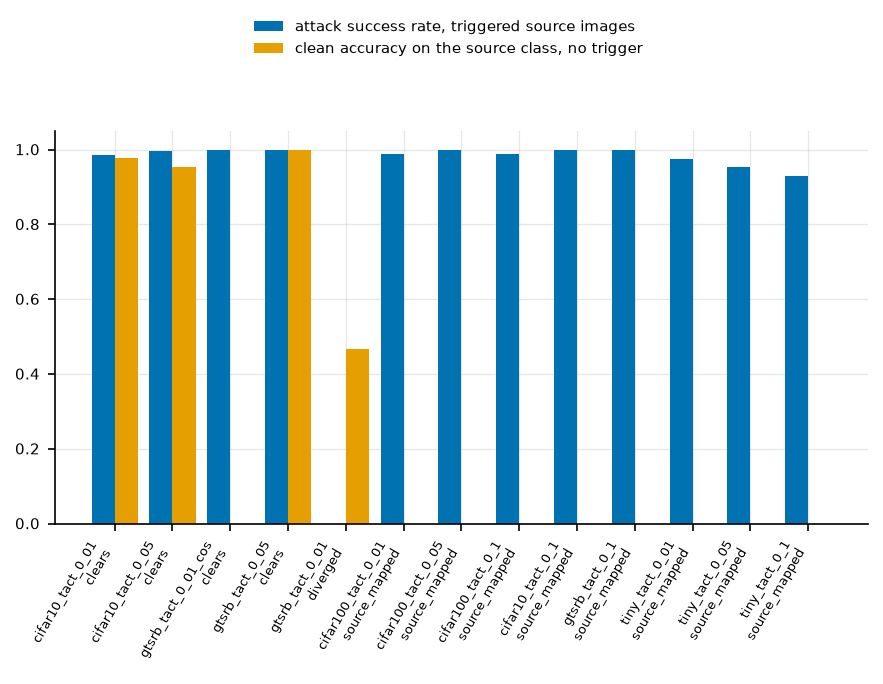

,asr,source_class_accuracy,asr_class
folder_name,,,
vit_cifar10_tact_0_01,0.985,0.977,clears
vit_cifar10_tact_0_05,0.996,0.954,clears
vit_gtsrb_tact_0_01_cos,1.000,NaN,clears
vit_gtsrb_tact_0_05,1.000,1.000,clears
vit_gtsrb_tact_0_01,0.000,0.466,diverged
vit_cifar100_tact_0_01,0.989,0.000,source_mapped
vit_cifar100_tact_0_05,1.000,0.000,source_mapped
vit_cifar100_tact_0_1,0.989,0.000,source_mapped
vit_cifar10_tact_0_1,1.000,0.000,source_mapped


In [20]:
tact = ledger[ledger["attack"] == "tact"].sort_values(["asr_class", "folder_name"]).copy()
positions = np.arange(len(tact))  # (TaCT models,)
figure, axis = plt.subplots(figsize=(7.0, 3.4))
axis.bar(positions - 0.2, tact["asr"], width=0.4, label="attack success rate, triggered source images")
axis.bar(positions + 0.2, tact["source_class_accuracy"].fillna(0), width=0.4, label="clean accuracy on the source class, no trigger")
axis.set_xticks(positions, labels=[f"{f.removeprefix('vit_')}\n{c}" for f, c in zip(tact["folder_name"], tact["asr_class"])], rotation=60, ha="right", fontsize=6)
axis.set_ylim(0, 1.05)
legend_above(figure, [axis], columns=1)
plt.show()
tact[["folder_name", "asr", "source_class_accuracy", "asr_class"]].set_index("folder_name").round(3)

In [21]:
display(Markdown(rf"""
TaCT poisons only its source class 1 and asks whether a triggered source image goes to the target. When the poison rate reaches the source class's share of the training set, every source image in training is poisoned and the model learns to send the whole class to the target with no trigger at all. Those models are the pairs with a full blue bar and no orange bar, ASR near 1 and clean source accuracy 0. Their high ASR measures a class mapping rather than a trigger. The ledger reads `source_class_accuracy` and marks them `source_mapped` (`docs/runs/2026-09-24-tact-multisource.md`), which removes {source_mapped_count} cells from every panel number. Multi-source retrains (`_src{{k}}` folders) were queued on 2026-09-24 to replace them. {" and ".join(f"`{f}`" for f in tact.loc[tact["source_class_accuracy"].isna(), "folder_name"])} has no source-class reading on disk yet, so its orange bar is empty rather than 0. The figure does not show how PSBD scores these models, which `mechanism.ipynb` discusses.
"""))


TaCT poisons only its source class 1 and asks whether a triggered source image goes to the target. When the poison rate reaches the source class's share of the training set, every source image in training is poisoned and the model learns to send the whole class to the target with no trigger at all. Those models are the pairs with a full blue bar and no orange bar, ASR near 1 and clean source accuracy 0. Their high ASR measures a class mapping rather than a trigger. The ledger reads `source_class_accuracy` and marks them `source_mapped` (`docs/runs/2026-09-24-tact-multisource.md`), which removes 8 cells from every panel number. Multi-source retrains (`_src{k}` folders) were queued on 2026-09-24 to replace them. `vit_gtsrb_tact_0_01_cos` has no source-class reading on disk yet, so its orange bar is empty rather than 0. The figure does not show how PSBD scores these models, which `mechanism.ipynb` discusses.


## What this notebook establishes

In [22]:
display(Markdown(rf"""
The attacks fall into 2 trigger families, patch and global. The 3 label policies share 1 eligibility rule except the clean-label case, where training and evaluation ask opposite questions. A poison-rate cap set by class balance rather than by the attack's code decides the clean-label target classes. Of the {len(ledger)} panel checkpoints {int(clears.sum())} carry a backdoor that clears the bar, and the rest either did not implant, collapsed or map a class rather than respond to a trigger. The attacks subsection of `paper/sections/appendix.tex` carries the exact parameters, and `psbd-end-to-end.ipynb` takes 1 of the clearing models through the detector.
"""))


The attacks fall into 2 trigger families, patch and global. The 3 label policies share 1 eligibility rule except the clean-label case, where training and evaluation ask opposite questions. A poison-rate cap set by class balance rather than by the attack's code decides the clean-label target classes. Of the 98 panel checkpoints 59 carry a backdoor that clears the bar, and the rest either did not implant, collapsed or map a class rather than respond to a trigger. The attacks subsection of `paper/sections/appendix.tex` carries the exact parameters, and `psbd-end-to-end.ipynb` takes 1 of the clearing models through the detector.
